<span style="color:blue">CODE TO FLAG VENDOR INVOICES FOR MANUAL REVIEW</span><br>
<span style="color:blue"> Objective:To predict wheter a vendor invoice should be flagged for manual approval based on abnormal cost frienght or delivery pattern,in order to reduce finanacial risk,improve operational efficiency, and prioritize human reviews where it adds most value
    
</span><br>
<span style="color:red">Result:An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically</span>

In [1]:
import sqlite3
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
conn = sqlite3.connect("C:/Users/anura/Downloads/ml project/data/inventory.db")
tables = pd.read_sql_query("Select name from sqlite_master where type = 'table'",conn)

In [3]:
for table in tables['name']:
    print( f'Table name: {table}')
    display(pd.read_sql_query(f"select * from {table} limit 5",conn))

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [4]:
purchase_agg_df = pd.read_sql_query("""
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dolars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""",conn)
purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_item_dolars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [5]:
pd.read_sql_query("""
SELECT
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
FROM vendor_invoice vi
""", conn)


,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


<span style="color:blue">NOW LETS JOIN THE TABLE WHICH WILL GIVE ME DATA TO TARIN THE MODEL
</span>

In [6]:
df=pd.read_sql_query("""
WITH purchase_agg AS(
    SELECT
        p.PONumber,
        count(distinct p.Brand) AS total_brands,
        sum(p.Quantity) AS total_item_quantity,
        sum(p.Dollars) AS total_item_dollars,
        avg(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.POnumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay
    
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
    
""", conn)
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [7]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [8]:
def create_invoice_risk_label(row):
    
    #Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1
        
    #Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
    
    return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

0    3693
1    1850
Name: flag_invoice, dtype: int64

<Axes: >

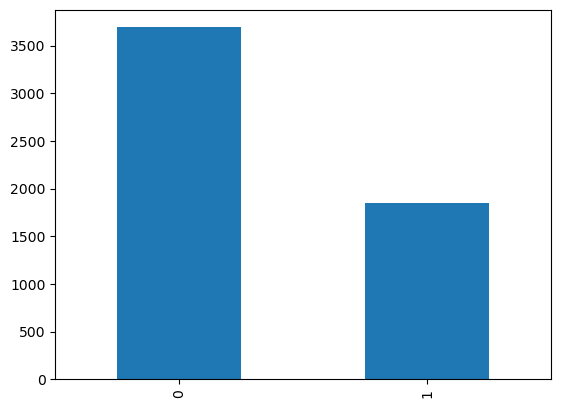

In [9]:
df["flag_invoice"].value_counts().plot(kind = 'bar')

<span style="color:blue">From the graph we can see flagged invoice is half</span>

<span style="color:blue">Lets see now how features are coorelated because the better features are correlated easier its for ML model to give prediction establishing relationship between input features and labels</span>

In [10]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


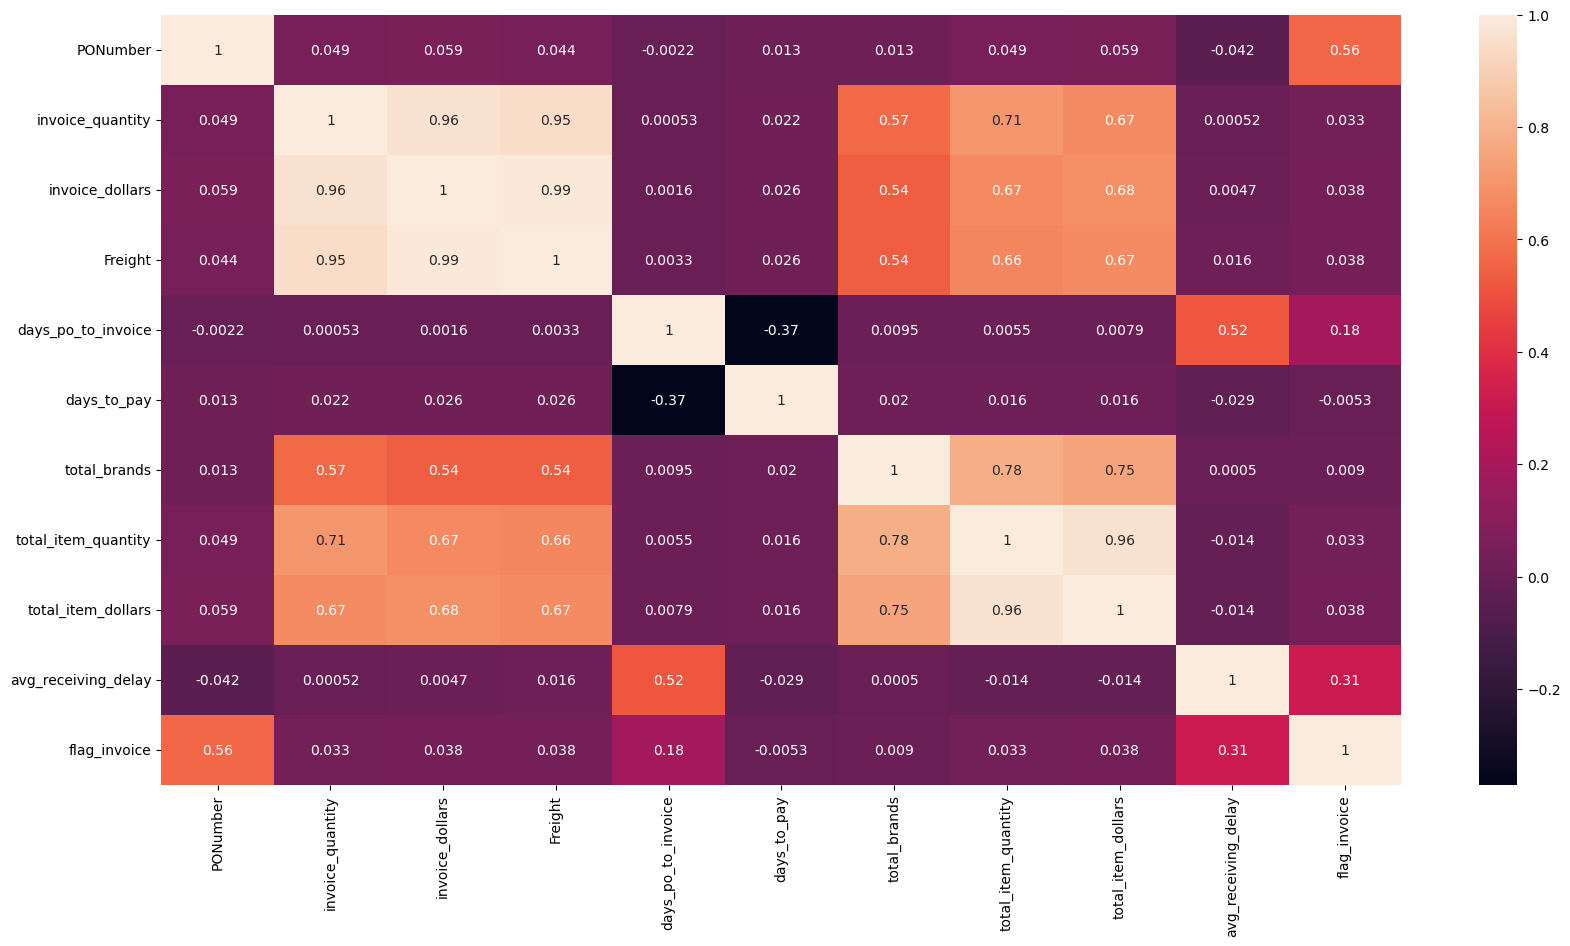

In [11]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot = True)
plt.show()

In [12]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [13]:
significant_features = []
non_significant_features = []
results = []

In [14]:
metrics = ["invoice_quantity", "invoice_dollars", "Freight", "days_po_to_invoice", "days_to_pay", "total_brands", "total_item_quantity", "total_item_dollars", "avg_receiving_delay"]

In [15]:
from scipy.stats import ttest_ind

for metric in metrics:
    
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()
    
    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )
    
    if p_value < 0.05:
        significant_features.append(metric)
        
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })
        
    else:
        non_significant_features.append(metric)
    

In [16]:
non_significant_features

['days_to_pay', 'total_brands']

In [17]:
 significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [18]:
print("Significant features:", significant_features)
print("Non significant features:", non_significant_features)
pd.DataFrame(results)

Significant features: ['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']
Non significant features: ['days_to_pay', 'total_brands']


,metric,flagged_mean,normal_mean,p_value
0,invoice_quantity,6728.28,5723.55,0.021
1,invoice_dollars,65600.61,54302.64,0.008
2,Freight,334.02,276.89,0.008
3,days_po_to_invoice,17.23,16.02,0.000
4,total_item_quantity,6728.28,5723.55,0.021
5,total_item_dollars,65600.61,54302.64,0.008
6,avg_receiving_delay,8.47,7.27,0.000


In [19]:
X = df[["invoice_quantity", "invoice_dollars", "Freight", "days_po_to_invoice","total_item_quantity", "total_item_dollars"]]
y = df["flag_invoice"]

In [20]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_quantity,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0
min,1.0,4.0,0.0,9.0,1.0,4.0
25%,83.0,968.0,5.0,14.0,83.0,968.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [24]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name):
    
    y_pred = model.predict(X_test)
    
    print(f"\n{model_name} Performance")
    
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", round(accuracy, 3))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [26]:
evaluate_model(model1, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(model2, X_test_scaled, y_test, "Decision Tree")
evaluate_model(model3, X_test_scaled, y_test, "Random Forest")


Logistic Regression Performance
Accuracy: 0.66

Confusion Matrix:
[[710  15]
 [362  22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.59      0.06      0.10       384

    accuracy                           0.66      1109
   macro avg       0.63      0.52      0.45      1109
weighted avg       0.64      0.66      0.55      1109


Decision Tree Performance
Accuracy: 0.822

Confusion Matrix:
[[633  92]
 [105 279]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       725
           1       0.75      0.73      0.74       384

    accuracy                           0.82      1109
   macro avg       0.80      0.80      0.80      1109
weighted avg       0.82      0.82      0.82      1109


Random Forest Performance
Accuracy: 0.879

Confusion Matrix:
[[707  18]
 [116 268]]

Classification Report:
              

<span style="color:blue">From the evaluation metrics we can conclude that RANDOM FOREST CLASSIFIER PERFORMS BEST so we will use it</span>

In [33]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Random Forest Classifier Performance
Accuracy: 0.885

Confusion Matrix:
[[706  19]
 [109 275]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



<span style="color:blue">In next step we will do hyperparameter tuning</span><br><span style="color:blue">It serves two main purpose it improves the overall accuracy of model and improve generalisation of model on unseen data.</span>

In [29]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "criterion": ["gini"]
}

In [30]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, "Random Forest Classifier")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Random Forest Classifier Performance
Accuracy: 0.888

Confusion Matrix:
[[713  12]
 [112 272]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       725
           1       0.96      0.71      0.81       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.88      1109



<span style="color:blue">We can notice slight increase in accuracy from 0.85 to 0.88</span>

In [36]:
from sklearn.metrics import confusion_matrix

In [37]:
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[713, 112],
       [ 12, 272]], dtype=int64)

In [38]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[706, 109],
       [ 19, 275]], dtype=int64)

In [40]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}